In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sgp4.api import Satrec, jday
from datetime import datetime, timezone, timedelta

merged = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/merged/ML_merged.parquet")
sgp4 = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/sgp4_positions.parquet")
tle = pd.read_parquet("/home/darshani/lightkurve-env/space-debris-detector/data/cleaned/tle_cleaned.parquet")

print(merged.shape, sgp4.shape)

(66666, 54) (37843, 12)


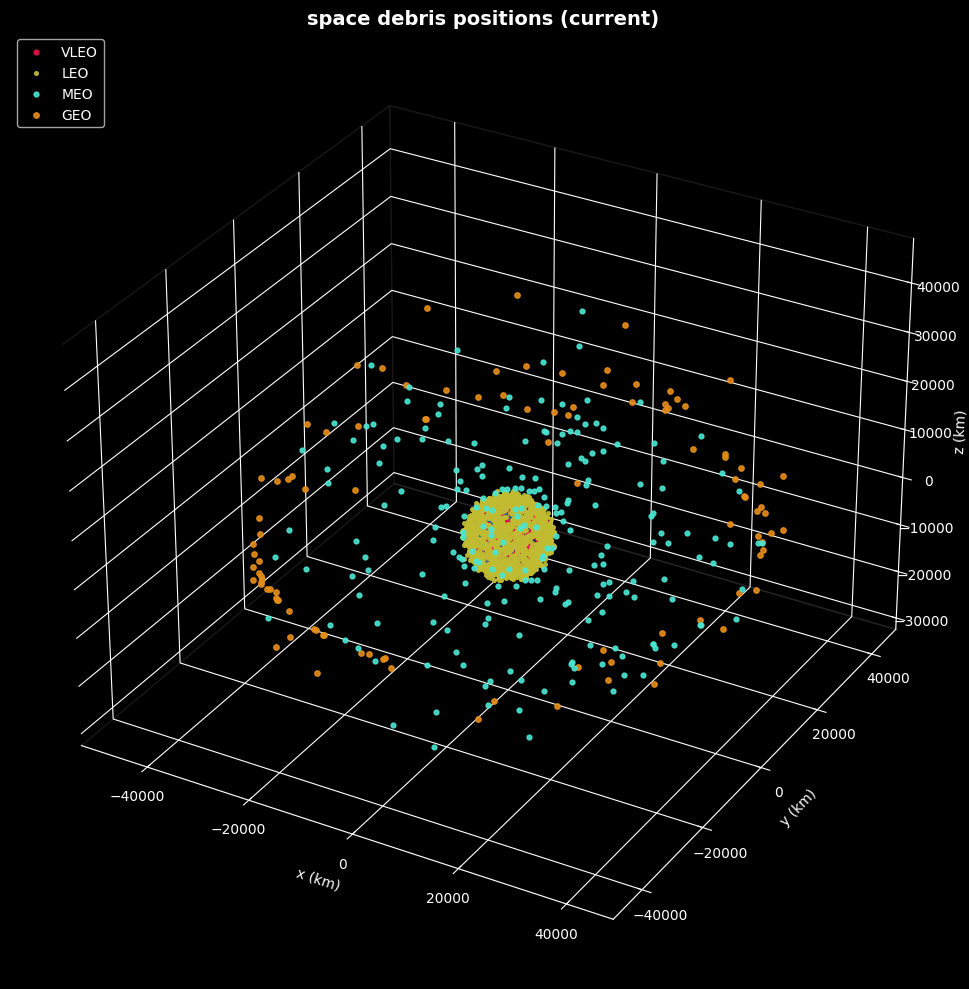

In [ ]:
plt.style.use('dark_background')

fig = plt.figure(figsize=(11, 10))
ax = fig.add_subplot(111, projection='3d')

# earth
u = np.linspace(0, 2*np.pi, 50)
v = np.linspace(0, np.pi, 50)
x = 6371 * np.outer(np.cos(u), np.sin(v))
y = 6371 * np.outer(np.sin(u), np.sin(v))
z = 6371 * np.outer(np.ones(np.size(u)), np.cos(v))
ax.plot_surface(x, y, z, color='#3498db', alpha=0.6, linewidth=0)

sample = sgp4[sgp4['altitude_km'].between(200, 42000)].sample(2000, random_state=42)

# plot each regime separately so they show up clearly
for regime, color, size in [('VLEO', "#E51149", 12), ('LEO', "#c1bc31", 7), ('MEO', "#49e6d3", 12), ('GEO', "#e68d19", 15)]:
    mask = sample['regime'] == regime
    if mask.sum() > 0:
        ax.scatter(sample[mask]['rx_km'], sample[mask]['ry_km'], sample[mask]['rz_km'],
                   c=color, s=size, alpha=0.9, depthshade=False, label=regime)

ax.set_title('space debris positions (current)', fontsize=14, fontweight='bold')
ax.set_xlabel('x (km)')
ax.set_ylabel('y (km)')
ax.set_zlabel('z (km)')
ax.set_facecolor('black')
ax.xaxis.pane.set_edgecolor("#323131")
ax.yaxis.pane.set_edgecolor("#323131")
ax.zaxis.pane.set_edgecolor('#323131')
ax.grid(True, color='#323131', linewidth=0.5)
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
fig.patch.set_facecolor('black')
ax.legend(loc='upper left', facecolor='black', labelcolor='white')
plt.tight_layout()
plt.show()

In [31]:
# pick an interesting object like ISS or a debris object
tle['NORAD_CAT_ID'] = pd.to_numeric(tle['NORAD_CAT_ID'], errors='coerce')

# ISS is NORAD 25544
obj = tle[tle['NORAD_CAT_ID'] == 25544].iloc[0]

sat = Satrec.twoline2rv(obj['TLE_LINE1'], obj['TLE_LINE2'])

# propagate every 5 mins for 24 hours
now = datetime.now(timezone.utc)
times = [now + timedelta(minutes=5*i) for i in range(288)]

positions = []
for t in times:
    jd, fr = jday(t.year, t.month, t.day, t.hour, t.minute, t.second)
    err, r, v = sat.sgp4(jd, fr)
    if err == 0:
        positions.append(r)

positions = np.array(positions)
print(f"propagated {len(positions)} points for ISS")

propagated 288 points for ISS


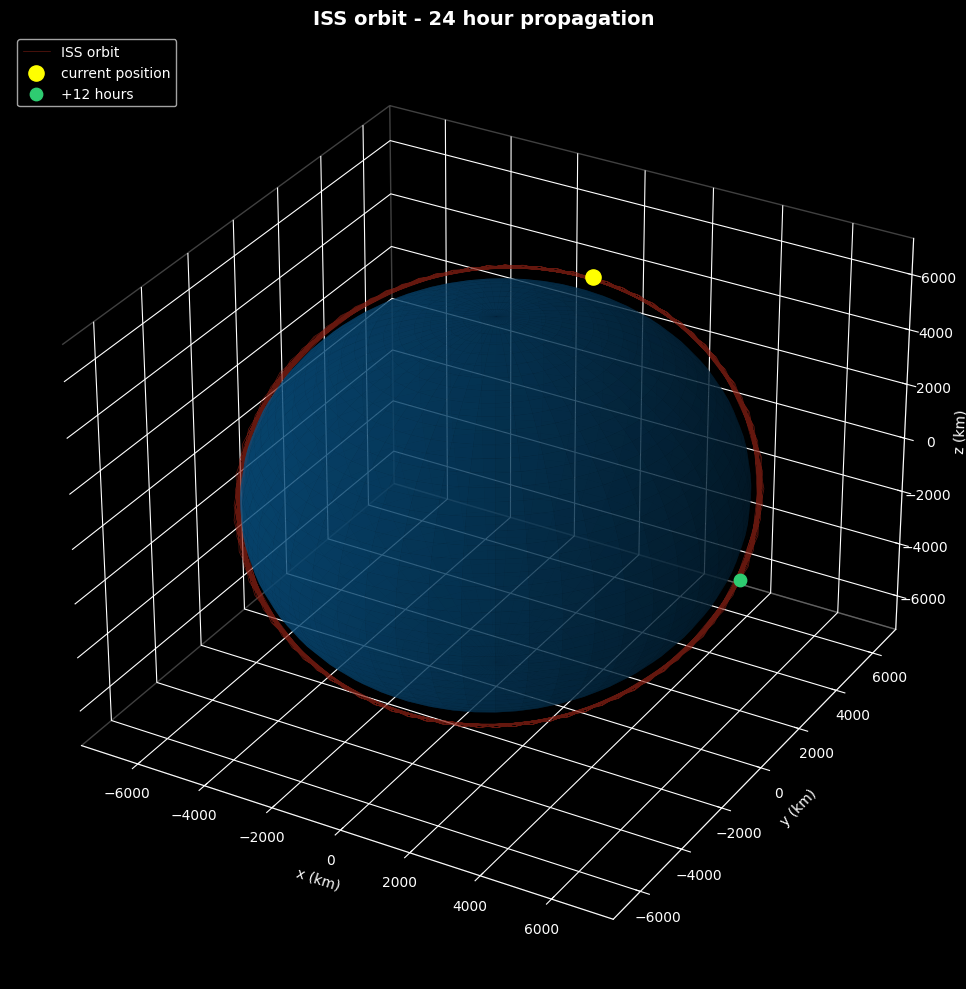

In [ ]:
fig = plt.figure(figsize=(11, 10), facecolor='black')
ax = fig.add_subplot(111, projection='3d')
ax.set_facecolor('black')
ax.xaxis.pane.set_edgecolor("#242121")
ax.yaxis.pane.set_edgecolor('#323131')
ax.zaxis.pane.set_edgecolor('#323131')
ax.grid(True, color='#323131', linewidth=0.5)

# earth
ax.plot_surface(x, y, z, color="#095182", alpha=0.6, linewidth=0)

# orbit path with gradient effect
ax.plot(positions[:, 0], positions[:, 1], positions[:, 2],
        color="#8f2115", linewidth=0.5, alpha=0.7, label='ISS orbit')

# current position
ax.scatter(positions[0, 0], positions[0, 1], positions[0, 2],
           color='yellow', s=120, zorder=5, label='current position')

# future position after 12 hours
ax.scatter(positions[144, 0], positions[144, 1], positions[144, 2],
           color='#2ecc71', s=80, zorder=5, label='+12 hours')

ax.set_title('ISS orbit - 24 hour propagation', fontsize=14, fontweight='bold', color='white')
ax.set_xlabel('x (km)', color='white')
ax.set_ylabel('y (km)', color='white')
ax.set_zlabel('z (km)', color='white')
ax.tick_params(colors='white')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('gray')
ax.yaxis.pane.set_edgecolor('gray')
ax.zaxis.pane.set_edgecolor('gray')
ax.legend(facecolor='black', labelcolor='white', loc='upper left')
plt.tight_layout()
plt.show()

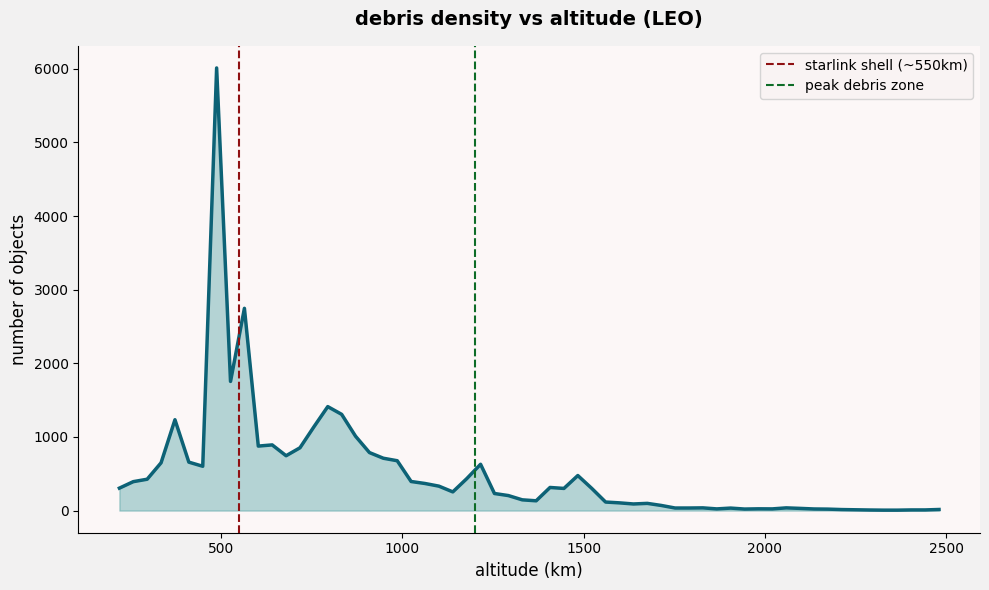

In [4]:
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor("#f2f1f1")
ax.set_facecolor("#fcf7f7")

clean = sgp4[sgp4['altitude_km'].between(200, 2500)].copy()

# bin it then plot as line
counts, bins = np.histogram(clean['altitude_km'], bins=60)
bin_centers = (bins[:-1] + bins[1:]) / 2

ax.plot(bin_centers, counts, color="#0d6276", linewidth=2.5)
ax.fill_between(bin_centers, counts, alpha=0.3, color="#0E8284")

ax.axvline(x=550, color="#8f1012", linestyle='--', linewidth=1.5, label='starlink shell (~550km)')
ax.axvline(x=1200, color="#0e6c27", linestyle='--', linewidth=1.5, label='peak debris zone')

ax.set_title('debris density vs altitude (LEO)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('altitude (km)', fontsize=12)
ax.set_ylabel('number of objects', fontsize=12)
ax.tick_params(colors='black')
ax.xaxis.label.set_color('black')
ax.yaxis.label.set_color('black')
ax.title.set_color('black')
ax.spines['bottom'].set_color('black')
ax.spines['left'].set_color('black')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(facecolor="#f9f3f3", labelcolor='black')
plt.tight_layout()
plt.show()

In [36]:
import joblib

model = joblib.load("/home/darshani/lightkurve-env/space-debris-detector/models/risk_model.pkl")
print(model)
print(model.n_estimators)
print(model.feature_importances_)

RandomForestClassifier(class_weight='balanced', random_state=42)
100
[0.08453616 0.03263546 0.15853011 0.10630942 0.15018322 0.15733565
 0.12267081 0.         0.04693559 0.06128639 0.02162679 0.02101749
 0.03693292]
